In [68]:
from pathlib import Path
import json

import numpy as np
import pandas as pd

from featuregraph_research.utils._arc_agi import solve_task, plot_arc_agi, get_known_transformations, get_valid_transformations, training_cycle, get_training_pairs, get_block_coordinates, get_candidate_transformations

In [69]:
def evaluate_task(task):
    predictions = solve_task(task)

    expected_outputs = [
        np.asarray(pair["output"], dtype=int)
        for pair in task["test"]
    ]

    exact = (
        len(predictions) == len(expected_outputs)
        and all(
            np.array_equal(prediction, expected)
            for prediction, expected in zip(
                predictions,
                expected_outputs,
                strict=True,
            )
        )
    )

    return {
        "supported": True,
        "exact": exact,
    }

In [70]:
def evaluate_challenges(challenges):
    results = {}

    for task_id, task in challenges.items():
        try:
            results[task_id] = evaluate_task(task)
        except ValueError as error:
            results[task_id] = {
                "supported": False,
                "exact": False,
                "failure": str(error),
            }

    return results

In [71]:
task_path = Path("../data/arc-agi-2/00576224.json")

with task_path.open(encoding="utf-8") as file:
    task = json.load(file)

challenges = {
    task_path.stem: task,
}

challenges.keys()

dict_keys(['00576224'])

In [72]:
results = evaluate_challenges(challenges)

number_supported = sum(
    result["supported"]
    for result in results.values()
)

number_exact = sum(
    result["exact"]
    for result in results.values()
)

number_fallback = len(results) - number_supported

{
    "tasks": len(results),
    "supported": number_supported,
    "exact_solved": number_exact,
    "supported_but_incorrect": number_supported - number_exact,
    "fallback": number_fallback,
}

{'tasks': 1,
 'supported': 1,
 'exact_solved': 1,
 'supported_but_incorrect': 0,
 'fallback': 0}

In [73]:
evaluation_table = pd.DataFrame.from_dict(
    results,
    orient="index",
).rename_axis("task_id").reset_index()

evaluation_table

,task_id,supported,exact
0,00576224,True,True


In [74]:
training_directory = Path("../../ARC-AGI-2/data/training")

task_paths = sorted(training_directory.glob("*.json"))[:25]

challenges = {}

for task_path in task_paths:
    with task_path.open(encoding="utf-8") as file:
        challenges[task_path.stem] = json.load(file)

len(challenges)

25

In [75]:
list(challenges)[:5]

['00576224', '007bbfb7', '009d5c81', '00d62c1b', '00dbd492']

In [76]:
results = evaluate_challenges(challenges)

In [77]:
number_supported = sum(
    result["supported"]
    for result in results.values()
)

number_exact = sum(
    result["exact"]
    for result in results.values()
)

number_fallback = len(results) - number_supported

{
    "tasks": len(results),
    "supported": number_supported,
    "exact_solved": number_exact,
    "supported_but_incorrect": number_supported - number_exact,
    "fallback": number_fallback,
}

{'tasks': 25,
 'supported': 2,
 'exact_solved': 2,
 'supported_but_incorrect': 0,
 'fallback': 23}

In [78]:
evaluation_table = pd.DataFrame.from_dict(
    results,
    orient="index",
).rename_axis("task_id").reset_index()

evaluation_table

,task_id,supported,exact,failure
0,00576224,True,True,NaN
1,007bbfb7,True,True,NaN
2,009d5c81,False,False,No solver family matched the task. fixed: No o...
3,00d62c1b,False,False,No solver family matched the task. fixed: No o...
4,00dbd492,False,False,No solver family matched the task. fixed: No o...
5,017c7c7b,False,False,No solver family matched the task. fixed: Outp...
6,025d127b,False,False,No solver family matched the task. fixed: No o...
7,03560426,False,False,No solver family matched the task. fixed: No o...
8,045e512c,False,False,No solver family matched the task. fixed: No o...
9,0520fde7,False,False,No solver family matched the task. fixed: Outp...


In [79]:
def categorize_failure(failure):
    if pd.isna(failure):
        return np.nan

    if "Output cannot be divided into input-shaped blocks." in failure:
        return "output_not_input_tiling"

    if "Training pairs have no shared operator" in failure:
        return "no_shared_operator"

    if "No operator matched block" in failure:
        return "no_registered_operator"

    if "Multiple operators remain" in failure:
        return "ambiguous_operator"

    return "other"

In [80]:
evaluation_table["failure_category"] = (
    evaluation_table["failure"].apply(categorize_failure)
)

failure_summary = (
    evaluation_table["failure_category"]
    .value_counts(dropna=False)
    .rename_axis("failure_category")
    .reset_index(name="number_of_tasks")
)

failure_summary

,failure_category,number_of_tasks
0,no_registered_operator,19
1,output_not_input_tiling,4
2,NaN,2


In [81]:
failure_summary["percent_of_tasks"] = (
    100
    * failure_summary["number_of_tasks"]
    / len(evaluation_table)
)

failure_summary

,failure_category,number_of_tasks,percent_of_tasks
0,no_registered_operator,19,76.0
1,output_not_input_tiling,4,16.0
2,NaN,2,8.0


In [82]:
failure_examples = (
    evaluation_table
    .dropna(subset=["failure_category"])
    .groupby("failure_category")["task_id"]
    .agg(list)
)

failure_examples

failure_category
no_registered_operator     [009d5c81, 00d62c1b, 00dbd492, 025d127b, 03560...
output_not_input_tiling             [017c7c7b, 0520fde7, 0a1d4ef5, 0b148d64]
Name: task_id, dtype: object

In [83]:
representative_task_id = failure_examples[
    "no_registered_operator"
][0]

representative_task_id
representative_task = challenges[representative_task_id]

shape_rows = []

for pair_type in ("train", "test"):
    for pair_index, pair in enumerate(
        representative_task[pair_type]
    ):
        input_grid = np.asarray(pair["input"])

        output_grid = (
            np.asarray(pair["output"])
            if "output" in pair
            else None
        )

        shape_rows.append(
            {
                "pair_type": pair_type,
                "pair_index": pair_index,
                "input_shape": input_grid.shape,
                "output_shape": (
                    output_grid.shape
                    if output_grid is not None
                    else None
                ),
                "output_block_rows": (
                    output_grid.shape[0] // input_grid.shape[0]
                    if output_grid is not None
                    else None
                ),
                "output_block_columns": (
                    output_grid.shape[1] // input_grid.shape[1]
                    if output_grid is not None
                    else None
                ),
            }
        )

shape_table = pd.DataFrame(shape_rows)
shape_table

,pair_type,pair_index,input_shape,output_shape,output_block_rows,output_block_columns
0,train,0,"(14, 14)","(14, 14)",1,1
1,train,1,"(14, 14)","(14, 14)",1,1
2,train,2,"(14, 14)","(14, 14)",1,1
3,train,3,"(14, 14)","(14, 14)",1,1
4,train,4,"(14, 14)","(14, 14)",1,1
5,test,0,"(14, 14)","(14, 14)",1,1


In [85]:
input_grid = np.asarray(representative_task["train"][1]["input"])

instruction_table = pd.DataFrame({
    "block_row": np.indices(input_grid.shape)[0].ravel(),
    "block_column": np.indices(input_grid.shape)[1].ravel(),
    "input_value": input_grid.ravel(),
})

instruction_table["operator"] = np.where(
    instruction_table["input_value"] == 0,
    "background",
    "copy",
)

instruction_table

,block_row,block_column,input_value,operator
0,0,0,0,background
1,0,1,0,background
2,0,2,0,background
3,0,3,0,background
4,0,4,0,background
...,...,...,...,...
191,13,9,0,background
192,13,10,0,background
193,13,11,0,background
194,13,12,0,background


In [94]:
evaluation_table["failure_category"] = (
    evaluation_table["failure"].apply(categorize_failure)
)

failure_summary = (
    evaluation_table["failure_category"]
    .value_counts(dropna=False)
    .rename_axis("failure_category")
    .reset_index(name="number_of_tasks")
)

failure_examples = (
    evaluation_table
    .dropna(subset=["failure_category"])
    .groupby("failure_category")["task_id"]
    .agg(list)
)

failure_summary

,failure_category,number_of_tasks
0,no_registered_operator,19
1,output_not_input_tiling,4
2,NaN,2


In [95]:
representative_task_id = failure_examples[
    "no_registered_operator"
][0]

representative_task_id

'009d5c81'

train[0]


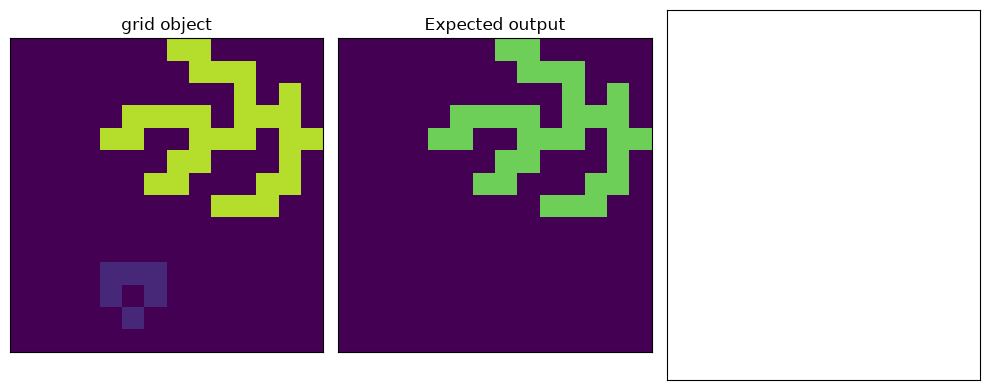

train[1]


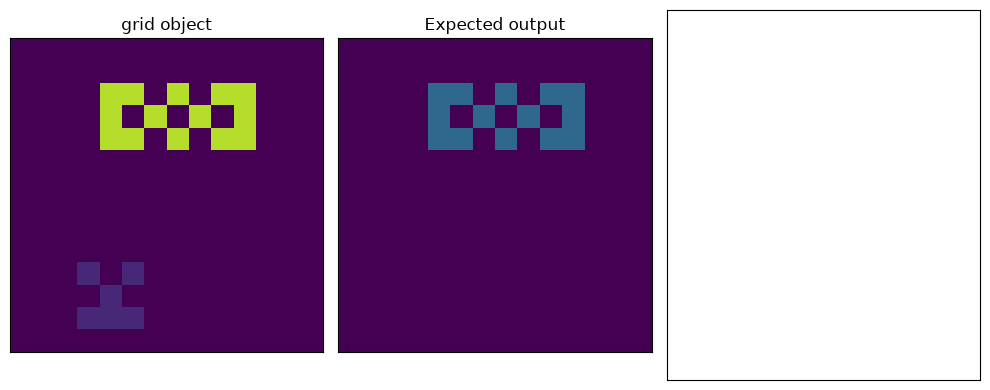

train[2]


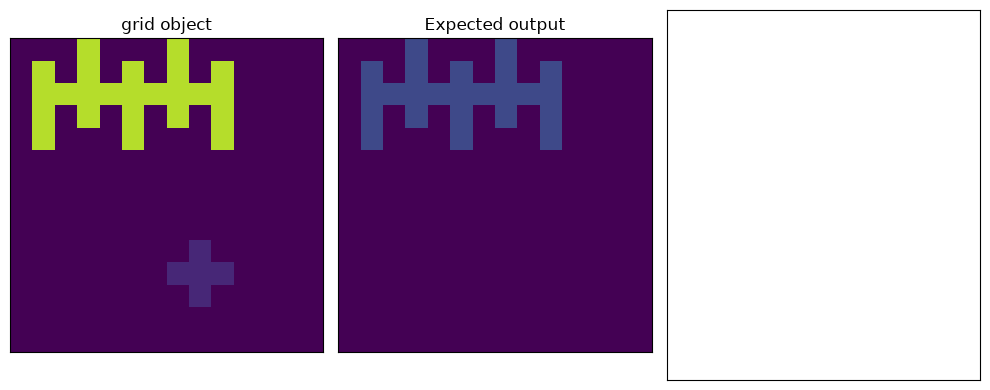

train[3]


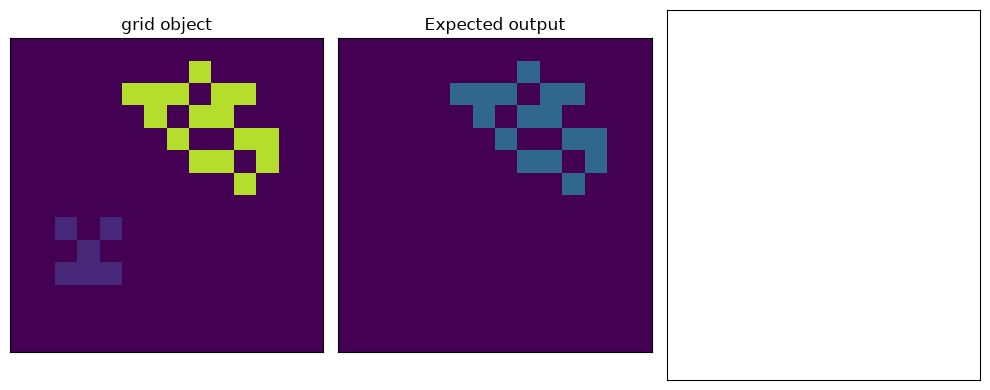

train[4]


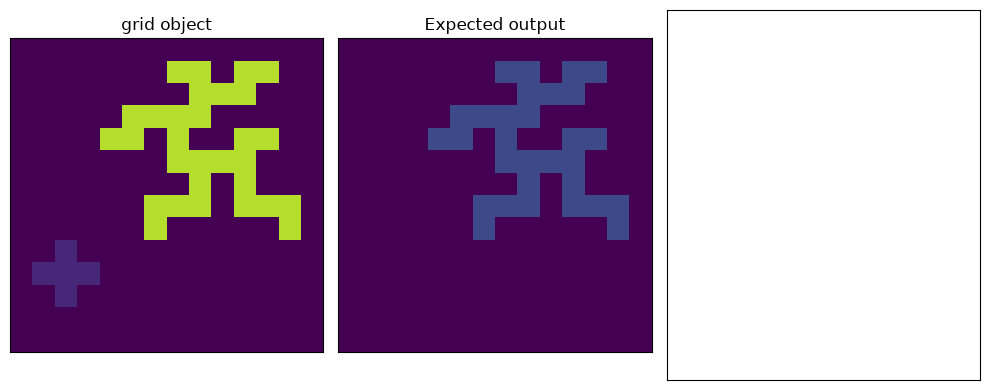

test[0]


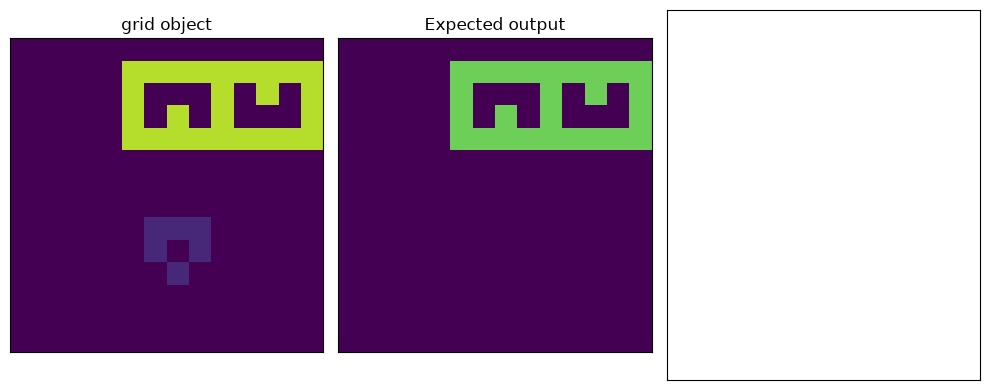

In [97]:
for pair_index, pair in enumerate(representative_task["train"]):
    print(f"train[{pair_index}]")

    plot_arc_agi(
        np.asarray(pair["input"], dtype=int),
        np.asarray(pair["output"], dtype=int),
    )
    plt.show()

for pair_index, pair in enumerate(representative_task["test"]):
    print(f"test[{pair_index}]")

    plot_arc_agi(
        np.asarray(pair["input"], dtype=int),
        (
            np.asarray(pair["output"], dtype=int)
            if "output" in pair
            else None
        ),
    )
    plt.show()